In [1]:
model_path='ppo_experiments_GNN/ppo_run_20250919_034710/best_model.zip'
#model_path='ppo_experiments_GNN/ppo_run_20250514_184304/best_model.zip'
#model_path= 'ppo_experiments_DS/ppo_run_20250514_184258/best_model.zip'

In [2]:
from sb3_contrib.common.wrappers import ActionMasker
from stable_baselines3.common.vec_env import DummyVecEnv
from Environment import UAVEnv

env=UAVEnv()
env.reset()
def mask_fn(env):
    return [env.needs>env.progress]
env = ActionMasker(env, mask_fn)

## defining test environment and test model
test_env = ActionMasker(UAVEnv(), mask_fn)
obs,info=test_env.reset()

In [3]:
obs, reward, done,truncated, info = env.step([2,2,2,2])
obs

{'needs': array([1.        , 1.        , 0.81237835, 1.        , 1.        ,
        1.        , 1.        , 1.        ]),
 'directions': array([ 0.07784173, -0.00990286, -0.48357725, -0.49130413, -0.10983694,
         0.3312488 , -0.15229175, -0.29863117]),
 'distance': array([0.27688857, 0.4830757 , 0.19268813, 0.41599617, 0.62528061,
        0.19993645, 0.66686601, 0.45436265]),
 'user_satisfied': array([False, False, False, False, False, False, False, False])}

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import trange
from sb3_contrib.ppo_mask import MaskablePPO

# =============================================================================
# Helpers for masked action selection
# =============================================================================

def get_valid_action(env):
    # Retrieve the action mask—assumes env.get_action_mask() returns a list of booleans.
    mask = env.get_action_mask()
    valid_actions = [i for i, valid in enumerate(mask) if valid]
    if not valid_actions:
        # Edge case: no valid actions; fall back on sampling from full space.
        return env.action_space.sample(), mask
    return np.random.choice(valid_actions), mask

def masked_policy_prediction(model, obs, env, deterministic=True):
    """
    Wraps the model's predict function to ensure that the predicted action
    adheres to the environment's mask. If the model returns an invalid action,
    sample uniformly among valid actions.
    """
    # Try to predict using the model (the model should be a Maskable* algorithm)
    action, _ = model.predict(obs, deterministic=deterministic)
    mask = mask_fn(env)
    # If the predicted action is not allowed, choose a valid one.
    if not mask[action]:
        valid_actions = [i for i, valid in enumerate(mask) if valid]
        if valid_actions:
            # Optionally, you could log or count these occurrences.
            action = np.random.choice(valid_actions)
        else:
            action = env.action_space.sample()
    return action

def masked_random_policy(env):
    """
    A random policy that only samples from actions allowed by the mask.
    """
    mask = mask_fn(env)
    valid_actions = [i for i, valid in enumerate(mask) if valid]
    if valid_actions:
        return np.random.choice(valid_actions)
    else:
        return env.action_space.sample()

def masked_greedy_policy(env):
    """
    A rule-based (greedy) policy that selects the user with the highest unmet need,
    but only if that action is allowed by the mask.
    """
    # Example: suppose env has attributes `needs` and `progress`
    remaining = env.needs - env.progress
    # Set remaining need to -inf for users that are not selectable according to the mask.
    mask = mask_fn(env)
    for idx, valid in enumerate(mask):
        if not valid:
            remaining[idx] = -np.inf
    # If all are -inf (no valid actions) then fall back on a random valid action.
    if np.all(remaining == -np.inf):
        return masked_random_policy(env)
    return int(np.argmax(remaining))

def masked_FCFS_policy(env):
    """
    A rule-based policy that selects the user with the lowest distance,
    but only if that action is allowed by the mask.
    """
    active_distances= env.get_active_distances()
    active_distances[active_distances==0] =np.inf
    return int(np.argmin(active_distances))

# =============================================================================
# Evaluation and progress collection function
# =============================================================================

def evaluate_policy_with_masking(policy_fn, env, model=None, n_eval_episodes=10, 
                                 deterministic=True, max_steps=600):
    """
    Evaluate a given policy function that obeys the action mask.
    policy_fn: a function taking (env, obs, [model]) and returning an action.
         For random and greedy policies, model is ignored.
         For the RL policy, pass masked_policy_prediction as the policy_fn.
    env: the evaluation environment (which must implement get_action_mask())
    model: only needed for the RL policy if policy_fn uses it.
    Returns:
        progress_record: an array of shape [n_timesteps, num_users] (per episode)
        metrics: a dict of cumulative reward and other custom metrics.
    """
    all_progress = []          # to record per-timestep user progress (e.g., satisfaction level)
    cumulative_rewards = []
    # You can also add lists for user_delay, throughput, etc.
    
    # Run one full episode and record progress at each step.
    obs,info = env.reset()
    done = False
    ep_reward = 0.0
    progress_record = []  # shape: [timesteps, num_users]
    JFI_record=[]
    Reward_record=[]
    BW_record=[]
    THr_fairness_record=[]
    
    for t in range(max_steps):
        # Record progress from the (unwrapped) environment.
        # (When using a vectorized env like DummyVecEnv, you might need to index it via env.envs[0])
        # Here we assume `env` has an attribute "progress" that's a NumPy array.
        try:
            # In a DummyVecEnv, use env.envs[0] (adjust if needed).
            current_progress = env.envs[0].progress.copy()
        except AttributeError:
            current_progress = env.progress.copy()
            
        progress_record.append(current_progress)
        
        # Depending on the policy, get action.
        if model is not None:
            # Use the RL policy with action-masking check.
            action = masked_policy_prediction(model, obs, env, deterministic=deterministic)
        else:
            # For baselines, policy_fn takes the env as argument.
            action = policy_fn(env)
        #print(action)
        obs, reward, done,truncated, info = env.step(action)
        ep_reward += reward
        
        JFI_fairness= info["JFI"]
        Throuput_fairness= info["Thr_fairness"]
        Temporal_bandwidth= info["Bandwidth"]
        JFI_record.append(JFI_fairness)
        Reward_record.append(ep_reward)
        BW_record.append(Temporal_bandwidth)
        THr_fairness_record.append(Throuput_fairness)
 
        
        if done:
            break

    cumulative_rewards.append(ep_reward)
    # Convert progress_record to a NumPy array [timesteps, num_users]
    progress_record = np.array(progress_record)
    JFI_record =np.array(JFI_record)
    Reward_record =np.array(Reward_record)
    BW_record =np.array(BW_record)
    THr_fairness_record= np.array(THr_fairness_record)
    # Here you could also compute additional custom metrics such as:
    # - Average user delay (if delay is computed within info or via env)
    # - Throughput and fairness (Jain's Fairness Index), etc.
    # For illustration, we just compute the final progress (you may replace this with your logic)
    metrics = {"reward": np.mean(cumulative_rewards)}
    
    return progress_record, Reward_record,JFI_record, BW_record,THr_fairness_record

# =============================================================================
# Plotting function
# =============================================================================
def plot_user_progress_reward(progress_record,Reward_record, title_label):
    """
    progress_record: a 2D array with shape [n_timesteps, num_users]
    """
    num_users = progress_record.shape[1]
    plt.figure(figsize=(8, 5))
    for u in range(num_users):
        plt.plot(progress_record[:, u], label=f"User {u+1}", alpha=0.8)
    plt.plot(Reward_record,label="Reward")
    plt.xlabel("Time Step")
    plt.ylabel("Progress")
    plt.title(f"User Progress - {title_label}")
    plt.legend(fontsize="small", loc="lower right")
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    
def plot_user_progress(progress_record, title_label):
    """
    progress_record: a 2D array with shape [n_timesteps, num_users]
    """
    num_users = progress_record.shape[1]
    plt.figure(figsize=(8, 5))
    for u in range(num_users):
        plt.plot(progress_record[:, u], label=f"User {u+1}", alpha=0.8)
    plt.xlabel("Time Step")
    plt.ylabel("Progress")
    plt.title(f"User Progress - {title_label}")
    plt.legend(fontsize="small", loc="lower right")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

def plot_reward(reward_arrays, title_labels):
    """
    Plots multiple numpy arrays of rewards on the same graph with corresponding labels.

    Args:
        reward_arrays (list of np.ndarray): A list of numpy arrays, where each array
                                            represents the rewards of an algorithm.
        title_labels (list of str): A list of strings, where each string is the label
                                     for the corresponding reward array.
    """
    if len(reward_arrays) != len(title_labels):
        raise ValueError("The number of reward arrays must match the number of labels.")

    plt.figure(figsize=(10, 6))  # Adjust figure size as needed

    for i, rewards in enumerate(reward_arrays):
        plt.plot(rewards, label=title_labels[i])

    plt.xlabel("Episode/Step")
    plt.ylabel("Reward")
    plt.title("Reward Comparison")
    plt.legend()
    plt.grid(True)
    plt.show()

def plot_JFI(JFI_arrays, title_labels):
    """
    Plots multiple numpy arrays of rewards on the same graph with corresponding labels.

    Args:
        reward_arrays (list of np.ndarray): A list of numpy arrays, where each array
                                            represents the rewards of an algorithm.
        title_labels (list of str): A list of strings, where each string is the label
                                     for the corresponding reward array.
    """
    if len(reward_arrays) != len(title_labels):
        raise ValueError("The number of reward arrays must match the number of labels.")

    plt.figure(figsize=(10, 6))  # Adjust figure size as needed

    for i, JFI in enumerate(JFI_arrays):
        plt.plot(JFI, label=title_labels[i])

    plt.xlabel("Episode/Step")
    plt.ylabel("Reward")
    plt.title("Reward Comparison")
    plt.legend()
    plt.grid(True)
    plt.show()

# =============================================================================
# Example usage: setting up separate envs and evaluation for each policy
# =============================================================================

# Ensure you import ActionMasker from sb3_contrib!
from sb3_contrib.common.wrappers import ActionMasker
from stable_baselines3.common.vec_env import DummyVecEnv

# Define your mask function (adjust based on your UAVEnv implementation)
def mask_fn(env):
    # Assume that env.needs and env.progress are NumPy arrays
    # and the mask is True if progress is less than needs.
    return (env.needs > env.progress).tolist()

# Create evaluation environment instances for consistency.
def make_masked_env():
    # Create a new instance of your environment (replace UAVEnv with your class name).
    env = UAVEnv()
    # Wrap it with the Maskable wrapper (from sb3_contrib)
    env = ActionMasker(env, mask_fn)
    return env


/usr/local/lib/python3.8/dist-packages/gymnasium/core.py:311: UserWarning: WARN: env.copy to get variables from other wrappers is deprecated and will be removed in v1.0, to get this variable you can do `env.unwrapped.copy` for environment variables or `env.get_wrapper_attr('copy')` that will search the reminding wrappers.
  logger.warn(


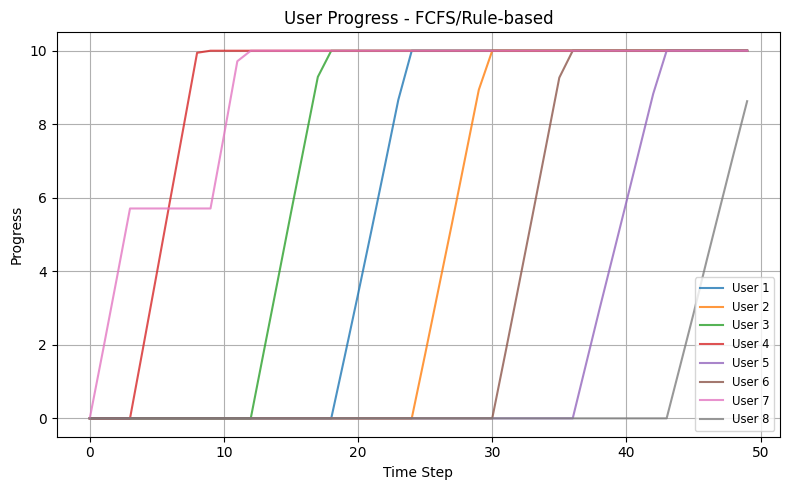

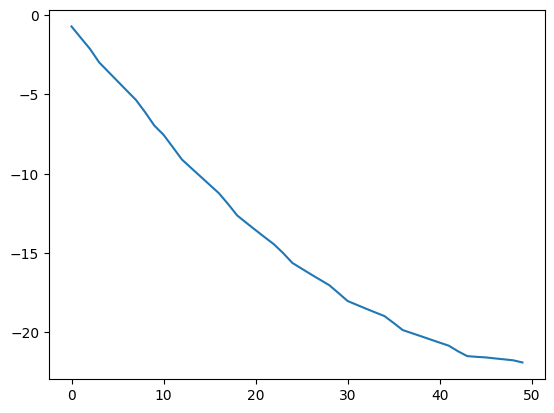

Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


/usr/local/lib/python3.8/dist-packages/gymnasium/core.py:311: UserWarning: WARN: env.envs to get variables from other wrappers is deprecated and will be removed in v1.0, to get this variable you can do `env.unwrapped.envs` for environment variables or `env.get_wrapper_attr('envs')` that will search the reminding wrappers.
  logger.warn(
/usr/local/lib/python3.8/dist-packages/gymnasium/core.py:311: UserWarning: WARN: env.progress to get variables from other wrappers is deprecated and will be removed in v1.0, to get this variable you can do `env.unwrapped.progress` for environment variables or `env.get_wrapper_attr('progress')` that will search the reminding wrappers.
  logger.warn(
/usr/local/lib/python3.8/dist-packages/gymnasium/core.py:311: UserWarning: WARN: env.needs to get variables from other wrappers is deprecated and will be removed in v1.0, to get this variable you can do `env.unwrapped.needs` for environment variables or `env.get_wrapper_attr('needs')` that will search the rem

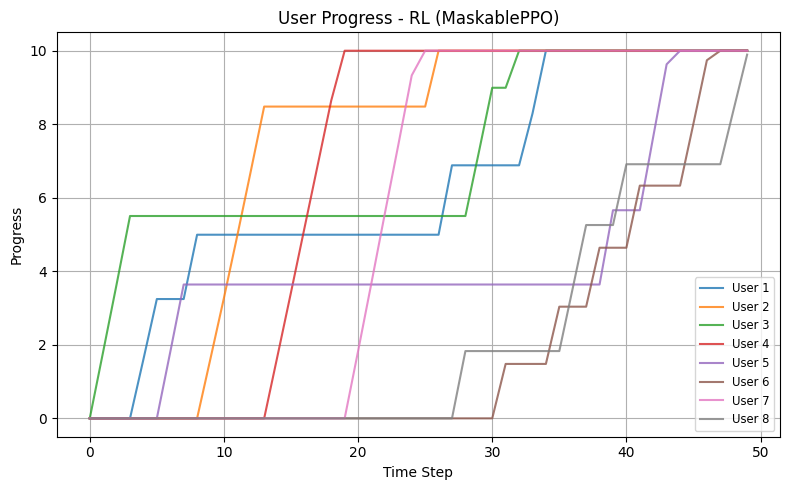

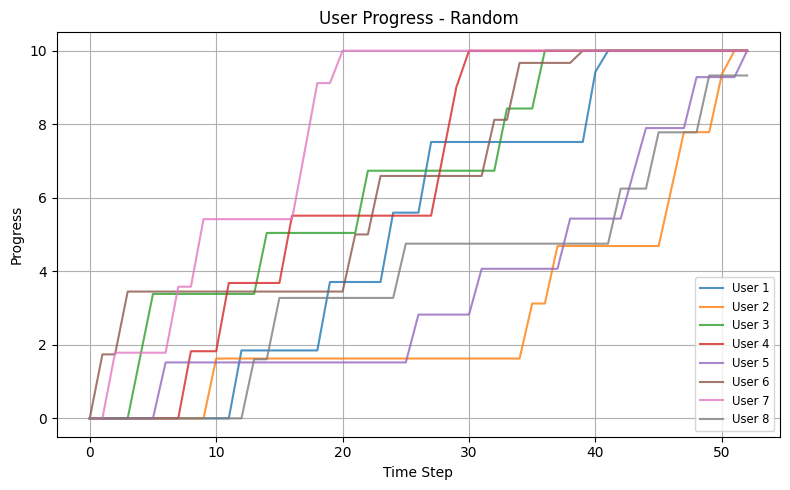

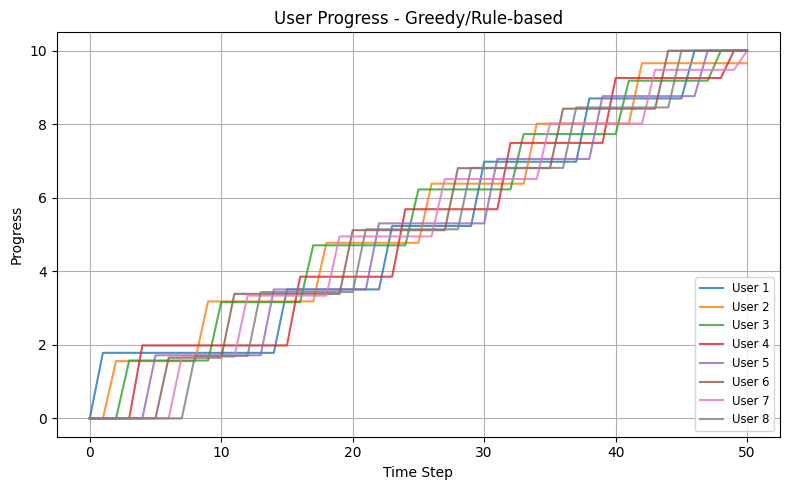

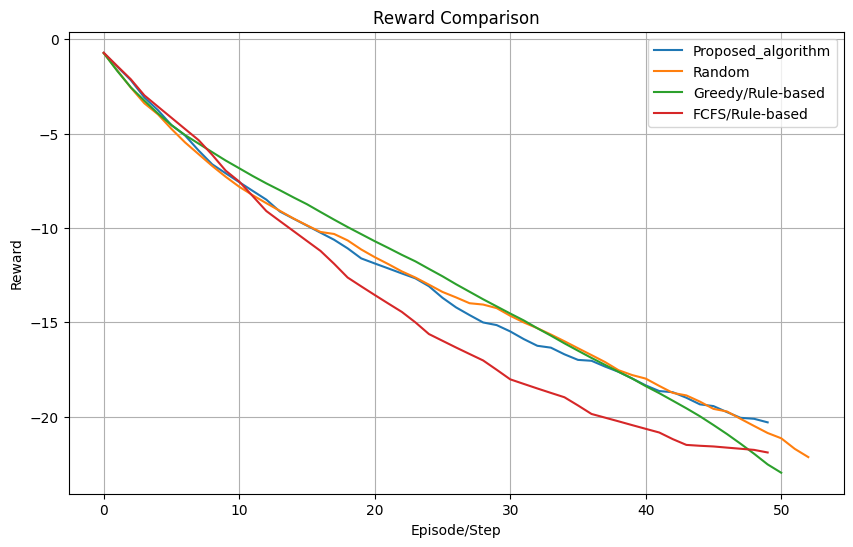

In [5]:
# Create separate DummyVecEnv instances (one per method)
rl_env = make_masked_env()
random_env = rl_env.copy()
greedy_env = rl_env.copy()
FCFS_env = rl_env.copy()

FCFS_progress, FCFS_reward, FCFS_jfi, FCFS_BW, FCFS_THr = evaluate_policy_with_masking(
                                                                masked_FCFS_policy, FCFS_env,
                                                               model=None, n_eval_episodes=1)
plot_user_progress(FCFS_progress,title_label="FCFS/Rule-based")
plt.plot(FCFS_reward)
plt.show()
# For the RL policy, load your trained MaskablePPO model (make sure its env is the masked one)
# from sb3_contrib.ppo_mask import MaskablePPO   <-- already imported when you train your model
trained_model = MaskablePPO.load(model_path, env=rl_env)

# Evaluate each policy:
RL_progress, RL_reward,RL_JFI, RL_BW, RL_THr = evaluate_policy_with_masking( 
                                                        masked_policy_prediction, rl_env,
                                                       model=trained_model, n_eval_episodes=1)

random_progress, rand_reward, rand_jfi, rand_BW, rand_THr = evaluate_policy_with_masking(
                                                            masked_random_policy, random_env,
                                                             model=None, n_eval_episodes=1)
greedy_progress, greedy_reward, greedy_jfi, greedy_BW, greedy_THr = evaluate_policy_with_masking(
                                                                masked_greedy_policy, greedy_env,
                                                               model=None, n_eval_episodes=1)



# Plot the per-user progress for each method.
plot_user_progress(RL_progress,title_label="RL (MaskablePPO)")
plot_user_progress(random_progress, title_label="Random")
plot_user_progress(greedy_progress, title_label="Greedy/Rule-based")

plot_reward([RL_reward, rand_reward, greedy_reward, FCFS_reward],
            title_labels=["Proposed_algorithm","Random", "Greedy/Rule-based","FCFS/Rule-based"])

In [6]:
obs, reward, done,info,_=rl_env.step(4)

active users [False False False False False False False False]
selected_user [4 4 4 4]


In [7]:
obs

{'needs': array([0., 0., 0., 0., 0., 0., 0., 0.]),
 'directions': array([0., 0., 0., 0., 0., 0., 0., 0.]),
 'distance': array([0.47338228, 0.72858587, 0.36928715, 0.68128273, 0.16323274,
        0.480657  , 0.47942381, 0.68553105]),
 'user_satisfied': array([ True,  True,  True,  True,  True,  True,  True,  True])}

In [8]:
reward

-40.4404875

In [9]:
done

True

In [10]:
info

False